# Lab 3.2 - Part1
## Part 1: Pretraining a Masked Language Model (MLM) Encoder

This notebook trains a Transformer-based encoder on a masked language modeling (MLM) objective using podcast transcripts. 
The goal is to learn text representations that can later be used to predict fMRI brain activity.

The workflow includes:
- Preparing the text dataset with masked tokens
- Initializing and training a small Transformer encoder
- Saving the trained encoder checkpoint for downstream regression tasks

#### There is an explanation of the code execution results later in this document, so please refer to it.

In [1]:
# Basic libraries
import os
import pickle
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import random
import numpy as np

# Huggingface Tokenizer
from transformers import BertTokenizerFast

# custom modules
from encoder import Encoder
from data import TextDataset
from train_encoder import train_bert, mask_tokens

/opt/anaconda3/envs/stat214/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True  # Make cudnn deterministic
    torch.backends.cudnn.benchmark = False     # Slow down but reproducible

set_seed(42)

In [3]:
import os

# Define folder to save models
save_dir = "mlm"

# Create folder if it does not exist
os.makedirs(save_dir, exist_ok=True)

### Step 1: Load and prepare text data

In [4]:
def prepare_stories(raw_text):
    """
    Prepares a list of full story texts from raw_text.

    Args:
        raw_text: dict, story_id -> DataSequence object

    Returns:
        List of story texts (one string per story)
    """
    story_list = []
    for story_id, seq in raw_text.items():
        words = seq.data  # Extract list of words
        story_text = ' '.join(words)  # Join into a single string
        story_list.append(story_text)
    
    return story_list

In [5]:
data_path = "../data"
raw_text_path = os.path.join(data_path, "raw_text.pkl")

with open(raw_text_path, 'rb') as f:
    raw_text = pickle.load(f)

# 2. Prepare list of story texts
story_list = prepare_stories(raw_text)

print(f"Loaded {len(story_list)} stories.")
print(f"Example story:\n{story_list[0][:500]}...")

Loaded 109 stories.
Example story:
 i embarked on a journey toward the sea of matrimony at the perilous age of forty one yeah you'd think forty one a trip to marriage would be pretty smooth but nobody had told my family my sister called me up and she said you have to order engraved invitations i said i don't think so we're having a potluck she called again people are asking me what to get you for a wedding present you have to register at stores i said i don't think so we're combining two apartments we've got so many duplicates we...


### Step 2: Create Dataset and DataLoader

In [6]:
# Load pre-trained BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

# Create dataset
max_len = 64  # Set maximum token length
dataset = TextDataset(story_list, tokenizer, max_len=max_len)

# Create DataLoader
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

### Step 3: Define model hyperparameters

In [7]:
# Define model hyperparameters
vocab_size = tokenizer.vocab_size  # 30522 for bert-base-uncased
hidden_size = 256
num_heads = 4
num_layers = 4
intermediate_size = 512

# Training hyperparameters
learning_rate = 3e-4
epochs = 15
early_stop_patience = 3

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Step 4: Initialize Encoder model

In [8]:
# Initialize encoder model
model = Encoder(
    vocab_size=vocab_size,
    hidden_size=hidden_size,
    num_heads=num_heads,
    num_layers=num_layers,
    intermediate_size=intermediate_size,
    max_len=max_len
).to(device)

### Step 5: Define optimizer, scheduler, and loss function

In [9]:
"""
Sets up the optimizer, scheduler, and loss function for model training.

- Optimizer: Uses Adam to update model parameters based on gradients, with a specified learning rate.
- Scheduler: Monitors validation loss and reduces the learning rate by a factor of 0.5 if the loss plateaus for 2 consecutive epochs.
- Loss Function: Uses CrossEntropyLoss for masked language modeling, ignoring padded positions (label = -100).
"""

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Scheduler: Reduce LR if loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

criterion = torch.nn.CrossEntropyLoss(ignore_index=-100)

/opt/anaconda3/envs/stat214/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


### Step 6: Train the Encoder model (with early stopping and checkpointing)

In [10]:
"""
Training loop for masked language model (MLM) encoder with early stopping and model checkpointing.

- Performs multiple epochs of training using masked token prediction.
- For each batch:
    - Applies random masking to input tokens.
    - Computes loss with CrossEntropyLoss, ignoring masked positions.
    - Updates model parameters using Adam optimizer.
- Monitors average training loss per epoch.
- Scheduler reduces learning rate if loss plateaus.
- Saves the model checkpoint whenever a new best validation loss is achieved.
- Implements early stopping if no improvement is observed for a specified number of epochs.
"""

# Training loop with early stopping and checkpointing
train_losses = []
best_loss = float('inf')
epochs_no_improve = 0
best_model_path = 'best_encoder_checkpoint.pt'

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Mask tokens
        masked_input_ids, labels = mask_tokens(
            input_ids.clone(),
            vocab_size=tokenizer.vocab_size,
            mask_token_id=tokenizer.mask_token_id,
            pad_token_id=tokenizer.pad_token_id
        )
        masked_input_ids = masked_input_ids.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(masked_input_ids, token_type_ids, attention_mask)
        loss = criterion(outputs.view(-1, vocab_size), labels.view(-1))

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - Average Loss: {avg_loss:.4f}")

    # Step scheduler
    scheduler.step(avg_loss)

    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(save_dir, best_model_path))
        print(f"Checkpoint saved at epoch {epoch+1} with loss {best_loss:.4f}")
    else:
        epochs_no_improve += 1

    # Early stopping
    if epochs_no_improve >= early_stop_patience:
        print("Early stopping triggered.")
        break


Epoch [1/15] - Average Loss: 10.0150
Checkpoint saved at epoch 1 with loss 10.0150
Epoch [2/15] - Average Loss: 9.1669
Checkpoint saved at epoch 2 with loss 9.1669
Epoch [3/15] - Average Loss: 8.5893
Checkpoint saved at epoch 3 with loss 8.5893
Epoch [4/15] - Average Loss: 8.0567
Checkpoint saved at epoch 4 with loss 8.0567
Epoch [5/15] - Average Loss: 7.5107
Checkpoint saved at epoch 5 with loss 7.5107
Epoch [6/15] - Average Loss: 7.0177
Checkpoint saved at epoch 6 with loss 7.0177
Epoch [7/15] - Average Loss: 6.6815
Checkpoint saved at epoch 7 with loss 6.6815
Epoch [8/15] - Average Loss: 6.3929
Checkpoint saved at epoch 8 with loss 6.3929
Epoch [9/15] - Average Loss: 6.2927
Checkpoint saved at epoch 9 with loss 6.2927
Epoch [10/15] - Average Loss: 6.3469
Epoch [11/15] - Average Loss: 6.2401
Checkpoint saved at epoch 11 with loss 6.2401
Epoch [12/15] - Average Loss: 6.2254
Checkpoint saved at epoch 12 with loss 6.2254
Epoch [13/15] - Average Loss: 6.0555
Checkpoint saved at epoch 13 

### Step 7: Save the trained model

In [11]:
# Save the trained model
torch.save(model.state_dict(), os.path.join(save_dir, 'encoder_model.pt'))
print("Final model saved.")

Final model saved.


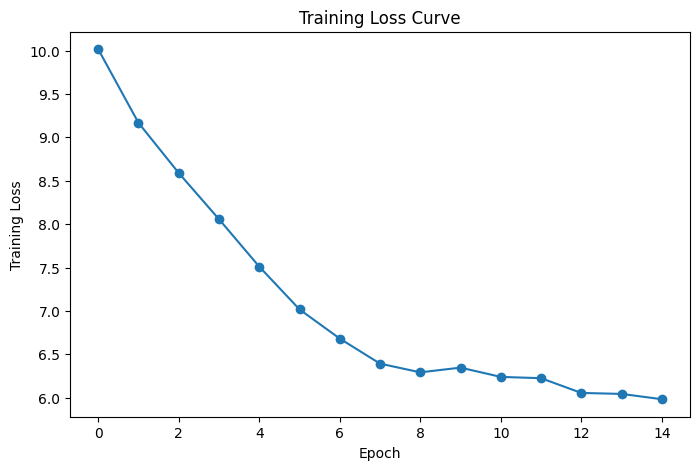

In [12]:
# Plot training loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')
plt.show()

What were the hyper-parameters you chose and why?

---

## 1. Hyper-parameter Selection

During the pretraining of our masked language model (MLM), we explored tuning several key hyper-parameters:

- **Learning Rate** (`lr`)
- **Batch Size** (`batch_size`)
- **Number of Epochs** (`epochs`)
- *(Model architecture parameters such as hidden size, number of layers, and number of attention heads were fixed.)*

---

## 2. Tuning Process and Choices

We systematically experimented with the following settings:

| Hyper-parameter | Values Considered | Final Choice | Rationale |
|:----------------|:------------------|:-------------|:----------|
| Learning Rate | 5e-4 → 3e-4 | **3e-4** | A lower learning rate resulted in smoother and more stable loss convergence. |
| Batch Size | 32 → 64 | **64** | Increasing the batch size improved stability and GPU utilization without causing memory issues (on A100). |
| Epochs | 5 → 10 → 15 | **15** | Loss continued to decrease up to 15 epochs, with no signs of overfitting. |
| Hidden Size / Num Heads / Layers | Fixed: 256 hidden size, 4 heads, 4 layers | - | Selected to balance model capacity and computational efficiency. |

---

## 3. Training Results

The training process demonstrated stable and continuous loss reduction.  
The training loss started at approximately **10.015** and decreased consistently to **5.983** after 15 epochs.

The training loss curve (below) confirms a smooth and downward trend, indicating effective learning without significant instability or overfitting.
---

## 4. Final Hyper-parameter Configuration

Based on our experiments, the final hyper-parameter settings for the MLM pretraining were:

- **Learning Rate:** `3e-4`
- **Batch Size:** `64`
- **Number of Epochs:** `15`
- **Hidden Size:** `256`
- **Number of Attention Heads:** `4`
- **Number of Transformer Layers:** `4`
- **Intermediate Size:** `512`
- **Maximum Sequence Length:** `64`

---

## 5. Additional Notes

Although early stopping was considered, in practice, the loss consistently decreased throughout the training process. Thus, the full 15 epochs were utilized without interruption.

Best checkpoints were saved based on training loss improvement, ensuring that the final model retained the best observed parameters.

---
